# 톤이 죽은 보색 vs 톤을 절제하지 않은 보색

세이지그린(`#719470`)과 연분홍색(`#E0B3B6`)은 색상환에서 서로 마주보는 보색이지만
충돌하지 않는다. 영상은 그 이유를 "둘 다 **톤이 죽어 있어서**"라고 설명한다.
이 스크립트는 그 말을 **숫자**로 확인한다.

- 색상(Hue) 각도 차이 → 보색인지
- 채도(Saturation / Chroma) → 톤이 죽었는지
- 명도(Lightness) → 두 색이 비슷한 밝기 영역에 있는지

비교 대상으로 같은 보색이지만 톤을 절제하지 않은 오렌지(`#D96629`)·틸블루(`#0093A5`)를 함께 계산한다.

필요 패키지: plotly, kaleido (표준 라이브러리 colorsys 만으로 수치 계산은 가능)

In [1]:
import colorsys
import math


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


def hex_to_rgb01(hex_str: str) -> tuple[float, float, float]:
    """'#RRGGBB' -> (r, g, b) 각 0.0~1.0"""
    h = hex_str.lstrip("#")
    return tuple(int(h[i : i + 2], 16) / 255 for i in (0, 2, 4))


PAIRS = {
    "세이지그린 & 연분홍색 (톤 죽음)": [("세이지그린", "#719470"), ("연분홍색", "#E0B3B6")],
    "오렌지 & 틸블루 (톤 절제 없음)": [("오렌지", "#D96629"), ("틸블루", "#0093A5")],
}

## 1. HSL / HSV 로 색상·채도·명도 뽑기

`colorsys.rgb_to_hls` 는 (H, L, S) 순서로 돌려준다. 색상은 $0 \le H < 1$ 이므로 $360$ 을 곱해 각도로 바꾼다.

주의: HSL 의 S 는 밝은 색에서 과장된다. 예컨대 연분홍은 HSL 채도가 42% 로 나오지만 실제로 '탁한' 색이다.
그래서 **크로마(Chroma)** 도 함께 본다. RGB 에서 크로마는

$$C = \max(R,G,B) - \min(R,G,B)$$

로, 색이 회색축에서 얼마나 떨어져 있는지를 직접 잰다. 회색이면 $C = 0$, 순색이면 $C = 1$.

In [2]:
def describe(hex_str: str) -> dict:
    r, g, b = hex_to_rgb01(hex_str)
    h, l, s_hsl = colorsys.rgb_to_hls(r, g, b)
    _, s_hsv, v = colorsys.rgb_to_hsv(r, g, b)
    chroma = max(r, g, b) - min(r, g, b)
    return {
        "hex": hex_str,
        "hue_deg": h * 360,
        "L_hsl": l * 100,
        "S_hsl": s_hsl * 100,
        "S_hsv": s_hsv * 100,
        "V": v * 100,
        "chroma": chroma * 100,
    }


for pair_name, colors in PAIRS.items():
    print(f"\n[{pair_name}]")
    for name, hx in colors:
        d = describe(hx)
        print(
            f"  {name:6s} {hx}  H={d['hue_deg']:6.1f}°  "
            f"L(HSL)={d['L_hsl']:5.1f}  S(HSL)={d['S_hsl']:5.1f}  "
            f"S(HSV)={d['S_hsv']:5.1f}  Chroma={d['chroma']:5.1f}"
        )


[세이지그린 & 연분홍색 (톤 죽음)]
  세이지그린  #719470  H= 118.3°  L(HSL)= 51.0  S(HSL)= 14.4  S(HSV)= 24.3  Chroma= 14.1
  연분홍색   #E0B3B6  H= 356.0°  L(HSL)= 79.0  S(HSL)= 42.1  S(HSV)= 20.1  Chroma= 17.6

[오렌지 & 틸블루 (톤 절제 없음)]
  오렌지    #D96629  H=  20.8°  L(HSL)= 50.6  S(HSL)= 69.8  S(HSV)= 81.1  Chroma= 69.0
  틸블루    #0093A5  H= 186.5°  L(HSL)= 32.4  S(HSL)=100.0  S(HSV)=100.0  Chroma= 64.7


## 2. 색상각 차이 — 정말 보색인가?

원 위의 두 각도 차이는 $360°$ 를 넘어가는 방향도 있으므로

$$\Delta H = \min\bigl(|H_1 - H_2|,\; 360° - |H_1 - H_2|\bigr)$$

로 계산한다. $\Delta H \approx 180°$ 이면 RGB 색상환에서의 보색이다.

오렌지·틸블루는 $166°$ 로 거의 정반대다. 세이지그린·연분홍은 RGB 색상환(HSL)에서는 $122°$ 로,
컴퍼스로 잰 180° 는 아니다. 그러나 영상의 색상환(그림 2·3)은 **위 노랑·오른쪽 빨강·아래 파랑·왼쪽 초록**의
화가용(RYB)·대립색 배치이고, 그 배치에서 **빨강↔초록**은 정확히 마주보는 보색이다.
헤링(Hering)의 대립색 이론에서도 빨강–초록은 같은 채널의 양 끝이다. 아래에서 CIELAB $a^*$ 축(음수=초록, 양수=빨강)으로 이를 확인한다.

In [3]:
def hue_diff(h1: float, h2: float) -> float:
    d = abs(h1 - h2) % 360
    return min(d, 360 - d)


for pair_name, colors in PAIRS.items():
    d1, d2 = (describe(hx) for _, hx in colors)
    print(f"{pair_name}: ΔH(HSL) = {hue_diff(d1['hue_deg'], d2['hue_deg']):.1f}°")

세이지그린 & 연분홍색 (톤 죽음): ΔH(HSL) = 122.3°
오렌지 & 틸블루 (톤 절제 없음): ΔH(HSL) = 165.8°


## 3. CIELAB 로 보기 — 대립색 축과 지각적 크로마

sRGB → 선형 RGB → XYZ → CIELAB 순서로 변환하면 지각에 더 가까운 좌표를 얻는다.

- $L^*$: 지각 명도 (0 검정 ~ 100 흰색)
- $a^*$: 초록(−) ↔ 빨강(+) 대립축
- $b^*$: 파랑(−) ↔ 노랑(+) 대립축
- 크로마 $C^*_{ab} = \sqrt{a^{*2} + b^{*2}}$, 색상각 $h_{ab} = \operatorname{atan2}(b^*, a^*)$

두 색의 $a^*$ 부호가 반대면 빨강–초록 채널에서 서로 반대 방향으로 자극하는 **대립색**이다.
그 대립이 얼마나 세게 느껴지는지는 $C^*_{ab}$ 의 크기가 결정한다.

In [4]:
def srgb_to_lab(hex_str: str) -> tuple[float, float, float]:
    def lin(c):
        return c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4

    r, g, b = (lin(c) for c in hex_to_rgb01(hex_str))
    # sRGB (D65) → XYZ
    x = 0.4124564 * r + 0.3575761 * g + 0.1804375 * b
    y = 0.2126729 * r + 0.7151522 * g + 0.0721750 * b
    z = 0.0193339 * r + 0.1191920 * g + 0.9503041 * b
    xn, yn, zn = 0.95047, 1.0, 1.08883  # D65 백색점

    def f(t):
        return t ** (1 / 3) if t > (6 / 29) ** 3 else t / (3 * (6 / 29) ** 2) + 4 / 29

    fx, fy, fz = f(x / xn), f(y / yn), f(z / zn)
    return 116 * fy - 16, 500 * (fx - fy), 200 * (fy - fz)


LAB = {}
for pair_name, colors in PAIRS.items():
    print(f"\n[{pair_name}]")
    for name, hx in colors:
        L, a, b = srgb_to_lab(hx)
        C = math.hypot(a, b)
        h = math.degrees(math.atan2(b, a)) % 360
        LAB[hx] = (L, a, b, C, h)
        print(f"  {name:6s} L*={L:5.1f}  a*={a:6.1f}  b*={b:6.1f}  C*={C:5.1f}  h={h:6.1f}°")
    (L1, a1, b1, C1, _), (L2, a2, b2, C2, _) = (LAB[hx] for _, hx in colors)
    print(f"  ΔL*={abs(L1 - L2):.1f}   a* 부호: {'반대(대립)' if a1 * a2 < 0 else '같음'}   평균 C*={(C1 + C2) / 2:.1f}")


[세이지그린 & 연분홍색 (톤 죽음)]
  세이지그린  L*= 57.9  a*= -19.6  b*=  15.2  C*= 24.8  h= 142.2°
  연분홍색   L*= 77.0  a*=  16.7  b*=   4.7  C*= 17.4  h=  15.6°
  ΔL*=19.1   a* 부호: 반대(대립)   평균 C*=21.1

[오렌지 & 틸블루 (톤 절제 없음)]
  오렌지    L*= 56.5  a*=  41.6  b*=  53.2  C*= 67.6  h=  52.0°
  틸블루    L*= 55.7  a*= -26.0  b*= -18.8  C*= 32.0  h= 215.8°
  ΔL*=0.8   a* 부호: 반대(대립)   평균 C*=49.8


## 4. 해석

| | 세이지그린·연분홍 | 오렌지·틸블루 |
|---|---|---|
| 대립색인가 | 예 ($a^*$ 부호 반대, RYB 색상환에서 정반대) | 예 ($\Delta H \approx 166°$) |
| 크로마 (RGB) | **14 / 18** — 둘 다 낮음 | **69 / 65** — 둘 다 높음 |
| 명도 (HSL L) | 51 / 79 — 둘 다 중간 이상, 어두운 색 없음 | 51 / 32 |

보색 대비의 세기는 "얼마나 반대 방향인가"(색상각)보다 "각 방향으로 **얼마나 멀리** 나갔는가"(크로마)가 좌우한다.
세이지그린·연분홍은 회색축에서 조금밖에 떨어지지 않아 대립축 위의 두 점 사이 거리가 짧고, 그래서 대비가 '눌린다'.
오렌지·틸블루는 두 점이 축의 양 끝으로 멀리 뻗어 있어 같은 보색이라도 팽팽하게 부딪힌다.
흥미롭게도 오렌지·틸블루는 $L^*$ 가 거의 같다(등명도). 밝기 차이가 없으니 경계는 오직 색 채널의 대립만으로 만들어지고,
그것이 '틸 앤 오렌지' 특유의 강한 분리감이다.

## 5. 시각화 — 스와치 + (크로마, 명도) 산점도

왼쪽·가운데: 두 쌍의 실제 색 스와치. 오른쪽: 각 색을 $x$=크로마, $y$=명도(HSL L)에 찍는다.
톤이 죽은 쌍은 왼쪽(저크로마)에 모여 있고, 톤을 절제하지 않은 쌍은 오른쪽(고크로마)에 흩어져 있다.

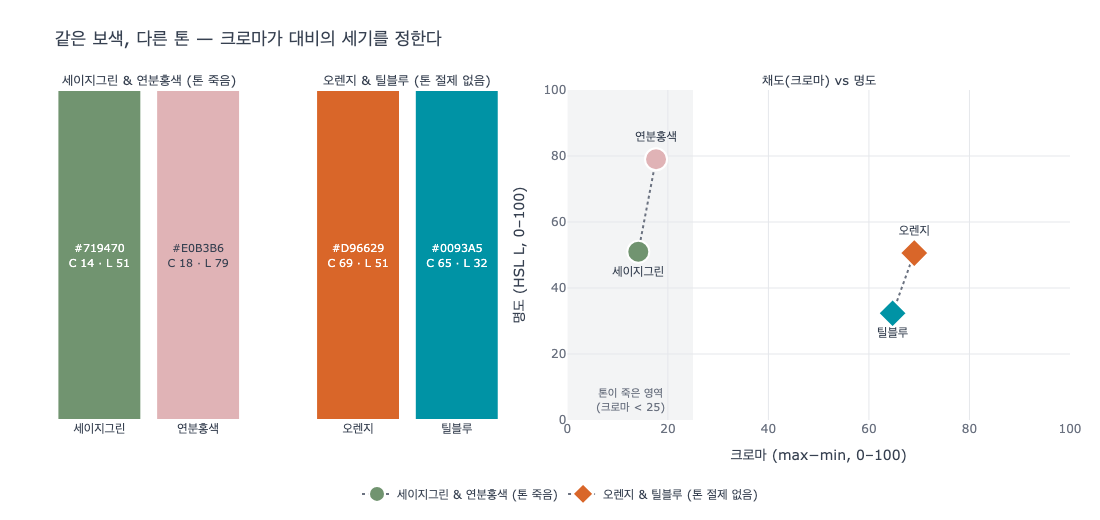

In [5]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

INK = "#374151"
MUTED = "#6B7280"
GRID = "#E5E7EB"

fig = make_subplots(
    rows=1,
    cols=3,
    column_widths=[0.22, 0.22, 0.56],
    subplot_titles=[*PAIRS.keys(), "채도(크로마) vs 명도"],
    horizontal_spacing=0.06,
)

# 스와치: 각 쌍을 두 개의 세로 막대로
for col, (pair_name, colors) in enumerate(PAIRS.items(), start=1):
    for name, hx in colors:
        d = describe(hx)
        fig.add_trace(
            go.Bar(
                x=[name],
                y=[1],
                marker=dict(color=hx, line=dict(color="#FFFFFF", width=2)),
                text=[f"{hx}<br>C {d['chroma']:.0f} · L {d['L_hsl']:.0f}"],
                textposition="inside",
                insidetextanchor="middle",
                textfont=dict(color="#FFFFFF" if d["L_hsl"] < 60 else INK, size=11),
                hovertemplate=f"{name} {hx}<br>H {d['hue_deg']:.0f}°, 크로마 {d['chroma']:.0f}, 명도 {d['L_hsl']:.0f}<extra></extra>",
                showlegend=False,
            ),
            row=1,
            col=col,
        )
    fig.update_yaxes(visible=False, range=[0, 1], row=1, col=col)
    fig.update_xaxes(showgrid=False, tickfont=dict(color=INK, size=12), row=1, col=col)

# 산점도: 쌍마다 두 점을 선으로 이어 '거리'를 보이게
symbols = {list(PAIRS)[0]: "circle", list(PAIRS)[1]: "diamond"}
for pair_name, colors in PAIRS.items():
    xs, ys, cs, names = [], [], [], []
    for name, hx in colors:
        d = describe(hx)
        xs.append(d["chroma"])
        ys.append(d["L_hsl"])
        cs.append(hx)
        names.append(name)
    fig.add_trace(
        go.Scatter(
            x=xs,
            y=ys,
            mode="lines+markers+text",
            line=dict(color=MUTED, width=2, dash="dot"),
            marker=dict(color=cs, size=22, symbol=symbols[pair_name], line=dict(color="#FFFFFF", width=2)),
            text=names,
            textposition=["top center" if ys[0] >= ys[1] else "bottom center", "bottom center" if ys[0] >= ys[1] else "top center"],
            textfont=dict(color=INK, size=12),
            name=pair_name,
            hovertemplate="%{text}<br>크로마 %{x:.0f}, 명도 %{y:.0f}<extra></extra>",
        ),
        row=1,
        col=3,
    )

# 저채도 영역 음영
fig.add_shape(
    type="rect", x0=0, x1=25, y0=0, y1=100, row=1, col=3,
    fillcolor="rgba(107,114,128,0.08)", line=dict(width=0), layer="below",
)
fig.add_annotation(
    x=12.5, y=6, text="톤이 죽은 영역<br>(크로마 < 25)", showarrow=False,
    font=dict(color=MUTED, size=11), row=1, col=3,
)

fig.update_xaxes(
    title_text="크로마 (max−min, 0–100)", range=[0, 100], gridcolor=GRID, zeroline=False,
    tickfont=dict(color=MUTED), title_font=dict(color=INK), row=1, col=3,
)
fig.update_yaxes(
    title_text="명도 (HSL L, 0–100)", range=[0, 100], gridcolor=GRID, zeroline=False,
    tickfont=dict(color=MUTED), title_font=dict(color=INK), row=1, col=3,
)
fig.update_layout(
    title=dict(text="같은 보색, 다른 톤 — 크로마가 대비의 세기를 정한다", font=dict(color=INK, size=18)),
    plot_bgcolor="#FFFFFF",
    paper_bgcolor="#FFFFFF",
    font=dict(color=INK),
    legend=dict(orientation="h", y=-0.18, x=0.5, xanchor="center", font=dict(color=INK)),
    margin=dict(l=50, r=30, t=90, b=90),
    width=1100,
    height=520,
    bargap=0.15,
)
fig.for_each_annotation(lambda a: a.update(font=dict(color=INK, size=13)) if a.text in list(PAIRS) + ["채도(크로마) vs 명도"] else None)

_show(fig)

In [6]:
import os

out_png = os.path.join(os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else ".", "expy.png")
fig.write_image(out_png, scale=2)
print("saved:", out_png)

saved: /Users/swcho/projects/swcho/flash-man/default/books/260923 그대로 갖다 쓰는 색깔 조합 16가지/.fm/hints/72a80431-6abe-4946-91ea-083eae725226/expy.png


![expy.png](expy.png)